# **1. Introduction:**

This is an EDA task that we wanna do some exploratory data analysis on the personality dataset. the following analysis include below sections:
- examining data types and structures
- handling missing data (data cleaning)
- de-duplication
- handling data-irregularities (outliers, anomaly, novelty, data drift)
- feature creation
- feature transformation
- feature extraction (future)
- feature selection (future)


In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import missingno
import preprocessing as pr

In [31]:
import sklearn

# sklearn version used in this project
sklearn.__version__

'1.8.0'

In [32]:
df = pd.read_csv("/mnt/d/Pytopia/Machine Learning/Applied-ML-Lab/data/raw/personality_dataset.csv")
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


**Features:**
- `Time_spent_Alone`: Hours spent alone daily (0–11).
- `Stage_fear`: Presence of stage fright (Yes/No).
- `Social_event_attendance`: Frequency of social events (0–10).
- `Going_outside`: Frequency of going outside (0–7).
- `Drained_after_socializing`: Feeling drained after socializing (Yes/No).
- `Friends_circle_size`: Number of close friends (0–15).
- `Post_frequency`: Social media post frequency (0–10).
- `Personality`: Target variable (Extrovert/Introvert).*

In [33]:
print("shape of the dataset:")
df.shape

shape of the dataset:


(2900, 8)

## **1.1. Examining Data Types and structures:**

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   str    
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   str    
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


In [35]:
df['Drained_after_socializing'] = df['Drained_after_socializing'].astype("category")
df['Stage_fear'] = df['Stage_fear'].astype("category")
df['Personality'] = df['Personality'].astype("category")
df

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert
...,...,...,...,...,...,...,...,...
2895,3.0,No,7.0,6.0,No,6.0,6.0,Extrovert
2896,3.0,No,8.0,3.0,No,14.0,9.0,Extrovert
2897,4.0,Yes,1.0,1.0,Yes,4.0,0.0,Introvert
2898,11.0,Yes,1.0,NaN,Yes,2.0,0.0,Introvert


In [36]:
# fixed dtypes
df.dtypes

Time_spent_Alone              float64
Stage_fear                   category
Social_event_attendance       float64
Going_outside                 float64
Drained_after_socializing    category
Friends_circle_size           float64
Post_frequency                float64
Personality                  category
dtype: object

## **1.2. Handling Missing Values:**

Text(0.5, 1.0, 'Nullity Matrix Plot')

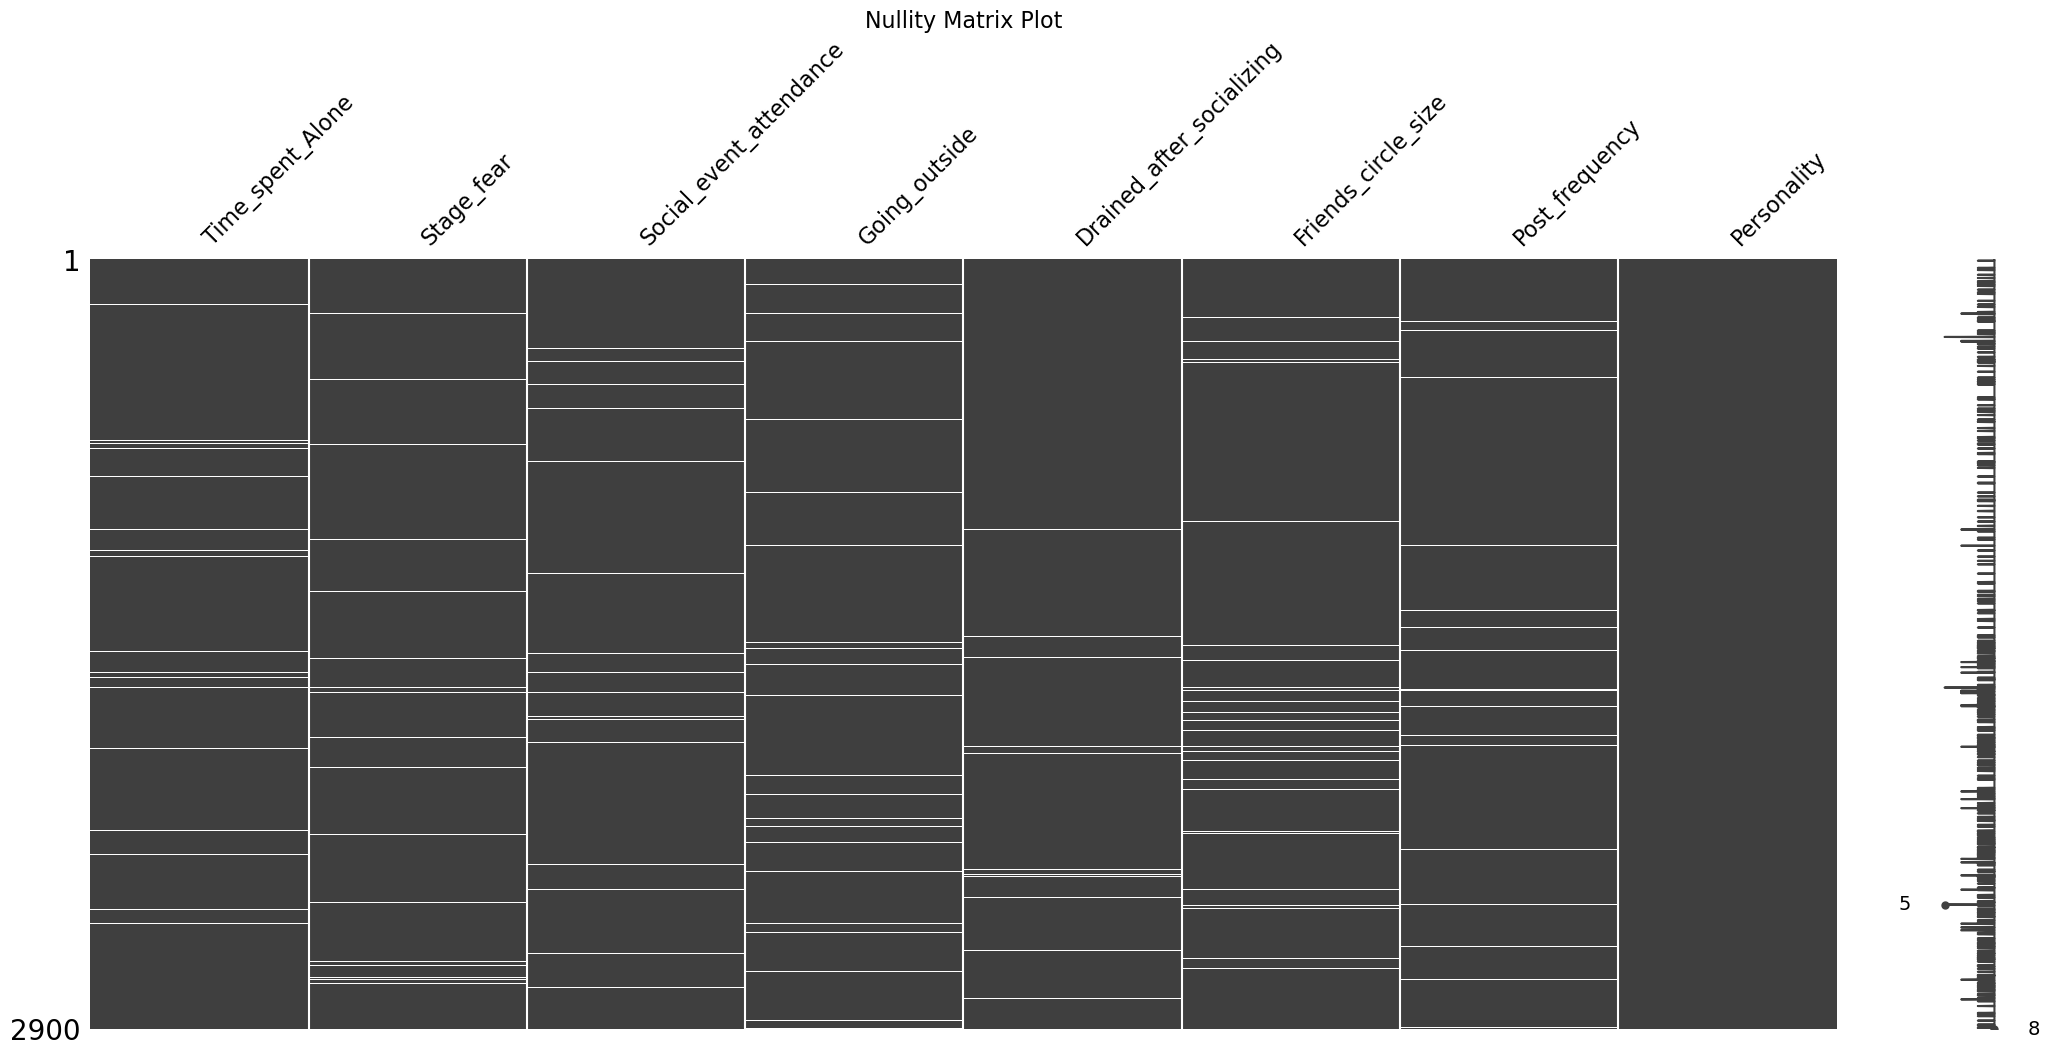

In [37]:
ax = missingno.matrix(df)
ax.set_title("Nullity Matrix Plot", fontsize=16)

In [38]:
pr.detect_mixed_types(df)

{'Stage_fear': {'str': 2827, 'float': 73},
 'Drained_after_socializing': {'str': 2848, 'float': 52}}

In [39]:
pr.missing_value_table(df)

Shape of the dataset: (2900, 8)
Number of Features with Missing Values: 7


,Missing Count,Missing Percentage
Friends_circle_size,77,2.655172
Stage_fear,73,2.517241
Going_outside,66,2.275862
Post_frequency,65,2.241379
Time_spent_Alone,63,2.172414
Social_event_attendance,62,2.137931
Drained_after_socializing,52,1.793103
Personality,0,0.000000


In [40]:
pr.categorize_missingness(df, 30)

Features with no missing values: ['Personality']
Features with lower than %30 missing values: ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency']
Features with higher than %30 missing values: []


<Axes: xlabel='Friends_circle_size', ylabel='Count'>

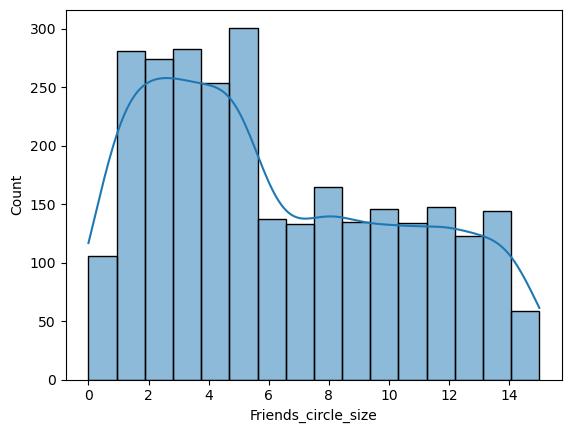

In [41]:
sns.histplot(data=df, x='Friends_circle_size', kde=True)

In [42]:
pr.describe(df)

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2837.000000,2838.000000,2834.000000,2823.000000,2835.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
median,4.000000,3.000000,3.000000,5.000000,3.000000
std,3.479192,2.903827,2.247327,4.289693,2.926582
variance,12.104779,8.432213,5.050477,18.401465,8.564881
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [ ]:
df['Friends_circle_size'].fillna(df.groupby(by="Personality")['Friends_circle_size'].median())

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert
...,...,...,...,...,...,...,...,...
2895,3.0,No,7.0,6.0,No,6.0,6.0,Extrovert
2896,3.0,No,8.0,3.0,No,14.0,9.0,Extrovert
2897,4.0,Yes,1.0,1.0,Yes,4.0,0.0,Introvert
2898,11.0,Yes,1.0,NaN,Yes,2.0,0.0,Introvert


<Axes: xlabel='Friends_circle_size', ylabel='Count'>

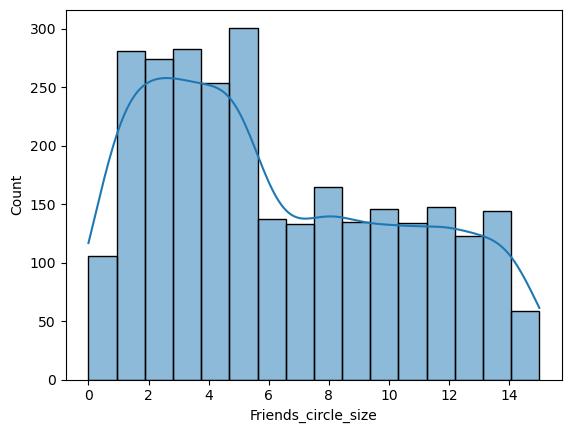

In [44]:
sns.histplot(data=df, x="Friends_circle_size", kde=True)

In [48]:
pr.missing_value_table(df)

Shape of the dataset: (2900, 8)
Number of Features with Missing Values: 7


,Missing Count,Missing Percentage
Friends_circle_size,77,2.655172
Stage_fear,73,2.517241
Going_outside,66,2.275862
Post_frequency,65,2.241379
Time_spent_Alone,63,2.172414
Social_event_attendance,62,2.137931
Drained_after_socializing,52,1.793103
Personality,0,0.000000


In [57]:
df[df['Friends_circle_size'].isnull()].loc[:, "Friends_circle_size"].fillna(1)

41      1.0
89      1.0
220     1.0
278     1.0
293     1.0
       ... 
2672    1.0
2712    1.0
2725    1.0
2767    1.0
2838    1.0
Name: Friends_circle_size, Length: 77, dtype: float64